# Prepare 20bn-jester-V1-videos Dataset

This notebook loads and extracts a subset of 14,000 (14 classes, 1000 videos per class) 20-bn-jester-v1 training videos for training a ResNet3D model following the kaggle notebook linked [here](https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d).
 
**Instructions:**
1. Download the full dataset .zip from Kaggle link [here](https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete/data)
2. Extract the .tgz file from the .zip file 
3. Run the notebook cell-by-cell

**Outputs:** 14,000 videos subsample

**Next: Use the subsample to generate train/val/test splits and pre-processing in notebook **02_data_preprocessing.ipynb****


**Data source reference:**

 * Sanjana T G. (2025). 20bn-jester-v1-complete (Version 1) [Data set]. Kaggle. https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete/data

**Github links to jester labels**:

* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv) to train labels. 
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-validation.csv) to validation labels.
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-test.csv) to test .csv.

**References for preprocessing:**
* https://www.kaggle.com/code/sanjanatg26/research-2
* https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d

In [ ]:
# Configure Device CPU/GPU usage 
import tensorflow as tf 
import torch
import torchvision
from tensorflow.python.client import device_lib

print( "PyTorch version : " , torch.__version__)
print( "CUDA Available : " , torch.cuda.is_available())
print( "torchvision version : " , torchvision.__version__)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(device_lib.list_local_devices())
print(torch.cuda.is_available()) # Returns True if GPU is available

# Check if TensorFlow uses the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            print(gpu)
            tf.config.experimental.set_memory_growth(gpu, True)
        print("TensorFlow is using the GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("TensorFlow is not using the GPU. Check your TensorFlow installation.")

PyTorch version :  2.6.0
CUDA Available :  False
torchvision version :  0.21.0
Num GPUs Available: 0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1243570011438936273
xla_global_id: -1
]
False
TensorFlow is not using the GPU. Check your TensorFlow installation.


In [3]:
import torch
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    print("GPU is available (MPS)")
else:
    print("GPU is NOT available")

GPU is available (MPS)


In [ ]:
# Imports 
import zipfile
import io
import csv
from pathlib import PurePosixPath
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# Check structure of .zip files 
with zipfile.ZipFile("./jester-v1/20bn-jester-v1.zip") as zf:
    for name in zf.namelist()[:200]:            # show first 200 entries
        print(name)
    # or search for any csv
    print([n for n in zf.namelist() if n.lower().endswith(".csv")])

20bn-jester-v1-complete.tgz
[]


## 1. Check: Extract a subset of 14,000 20bn-jester-v1 training video files

The following linked Kaggle notebook was referenced for extracting 14,000 jester video files (14 classes, 1000 videos per class) to train a ResNet3D model. 

Kaggle Notebook Reference: 
* https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d

In [ ]:
import os
import tarfile
import pandas as pd
import urllib.request

# Change to your working directory
working_dir = "./jester-v1/jester_uncompressed"
os.makedirs(working_dir, exist_ok=True)

csv_url = "https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv"
csv_local_path = os.path.join(working_dir, "jester-v1-train.csv")

urllib.request.urlretrieve(csv_url, csv_local_path)
print(f"-> CSV downloaded successfully to: {csv_local_path}")

print("2. Filtering for UI classes and Subsampling...")
df = pd.read_csv(csv_local_path, sep=';', header=None, names=['video_id', 'gesture'])
target_classes = [
    "Swiping Left", "Swiping Right", "Swiping Up", "Swiping Down",
    "Sliding Two Fingers Up", "Sliding Two Fingers Down", "Sliding Two Fingers Left", "Sliding Two Fingers Right",
    "Zooming In With Two Fingers", "Zooming Out With Two Fingers",
    "Drumming Fingers", "Pushing Two Fingers Away",
    "No gesture", "Doing other things"
]

# Keep only our targets
df = df[df['gesture'].isin(target_classes)]

# CRITICAL FIX: Limit to 1000 videos per class to save inodes and disk space
df = df.groupby('gesture').head(1000).reset_index(drop=True)

valid_ids = set(df['video_id'].astype(str))
print(f"-> Subsampled down to exactly {len(valid_ids)} videos.")

import zipfile
import tarfile

# ==============================
# 3. Auto-Locate the archive storing the .tgz data
# ==============================
print("3. Hunting for the .tgz archive...")
tar_path = None
for root, dirs, files in os.walk('./jester-v1/'):
    for file in files:
        if file.endswith('.tgz') or file.endswith('.tar.gz'):
            tar_path = os.path.join(root, file)
            break
    if tar_path: break

if not tar_path:
    raise FileNotFoundError("Could not find the .tgz archive. Ensure the dataset is attached!")
print(f"-> Found archive at: {tar_path}")

# ==============================
# 4. Bulletproof Extraction
# ==============================
print("4. Extracting the 14,000 required videos (This will be much faster now)...")
def extract_smartly(tar_obj, valid_video_ids):
    for member in tar_obj:
        parts = member.name.split('/')
        for part in parts:
            if part in valid_video_ids:
                yield member
                break

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=working_dir, members=extract_smartly(tar, valid_ids))

print("5. Extraction Complete! Data is ready for PyTorch.")

-> CSV downloaded successfully to: ./jester-v1/jester-v1-train.csv
2. Filtering for UI classes and Subsampling...
-> Subsampled down to exactly 14000 videos.
3. Hunting for the .tgz archive...
-> Found archive at: ./jester-v1/20bn-jester-v1-complete.tgz
4. Extracting the 14,000 required videos (This will be much faster now)...
5. Extraction Complete! Data is ready for PyTorch.


In [5]:
import torch
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.models.video as video_models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ==============================
# 1. Load Data (
# ==============================
# metadata_path = "/kaggle/working/jester_uncompressed/jester-v1-train.csv"

metadata_path = "./jester-v1/jester_uncompressed/jester-v1-train.csv"
print("Loading and filtering dataset...")
df = pd.read_csv(metadata_path, sep=';', header=None, names=['video_id', 'gesture'])

target_classes = [
    "Swiping Left", "Swiping Right", "Swiping Up", "Swiping Down",
    "Sliding Two Fingers Up", "Sliding Two Fingers Down", "Sliding Two Fingers Left", "Sliding Two Fingers Right",
    "Zooming In With Two Fingers", "Zooming Out With Two Fingers",
    "Drumming Fingers", "Pushing Two Fingers Away",
    "No gesture", "Doing other things"
]

clean_df = df[df['gesture'].isin(target_classes)].reset_index(drop=True)
clean_df = clean_df.groupby('gesture').head(1000).reset_index(drop=True)

# Safely auto-locate the extracted videos directory using a REAL video ID
sample_video_id = str(clean_df.iloc[0]['video_id'])
dataset_path = None
for root, dirs, files in os.walk('./jester-v1/jester_uncompressed'):
    if sample_video_id in dirs:
        dataset_path = root
        break

if not dataset_path:
    raise FileNotFoundError(f"Could not locate the folder containing video {sample_video_id}. Cell 1 may not have extracted correctly.")
print(f"Successfully locked onto extracted videos at: {dataset_path}")

all_labels = sorted(clean_df['gesture'].unique())
label_map = {label: idx for idx, label in enumerate(all_labels)}
print(f"Total UI Classes Locked: {len(label_map)}")

Loading and filtering dataset...
Successfully locked onto extracted videos at: ./jester-v1/jester_uncompressed/20bn-jester-v1
Total UI Classes Locked: 14


   video_id                       gesture
0     34870              Drumming Fingers
1     56557     Sliding Two Fingers Right
2    129112      Sliding Two Fingers Down
3    131717        Sliding Two Fingers Up
4     23595  Zooming Out With Two Fingers
(14000, 2)


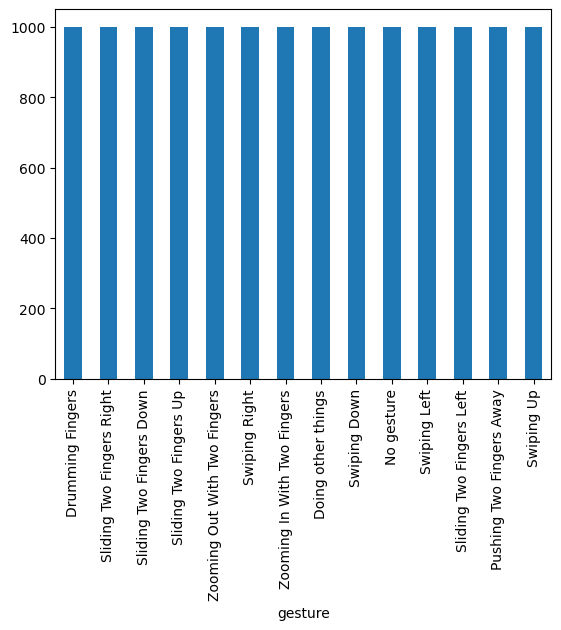

In [ ]:
# Checking df
print(clean_df.head())
from dataset_utils.JesterUIDataset import JesterUIDataset
print(clean_df.shape)

# Get counts for each class - verify there are 1000 for each class 
import pandas as pd
clean_df["gesture"].value_counts().plot(kind="bar")
plt.show()

## 2. Build and Train a ResNet3d Model
Goal: verify the data was loaded and processed correctly for ML model training.

## 

In [ ]:
# import JesterUIDataset
from dataset_utils.JesterUIDataset import JesterUIDataset
from torchvision import transforms
from torch.utils.data import DataLoader

# 3. Data Transformations & DataLoader
# ==============================
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
])

dataset = JesterUIDataset(dataframe=clean_df, root_dir=dataset_path, transform=transform, label_map=label_map)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

print("DataLoader initialized. Ready to fetch batches.")

# ==============================
# 4. Initialize the 3D Model
# ==============================
print("Initializing ResNet3D model...")
model = video_models.r3d_18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 14) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model successfully loaded onto: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==============================
# 5. The Training Loop
# ==============================
num_epochs = 1  # Just using 1 epoch to do a simple check 
print(f"Starting training loop for {num_epochs} epoch(s)...")

epoch_losses = []

for epoch in range(num_epochs):
    model.train() 
    running_loss = 0.0
    total_epoch_loss = 0.0
    num_batches = 0
    
    for i, (videos, labels) in enumerate(dataloader):
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        total_epoch_loss += loss.item()
        num_batches += 1
        
        if i % 50 == 49:
            print(f"[Epoch {epoch + 1}, Batch {i + 1}] Average Loss: {running_loss / 50:.3f}")
            running_loss = 0.0
            
    avg_epoch_loss = total_epoch_loss / num_batches
    epoch_losses.append(avg_epoch_loss)
    print(f"--- Epoch {epoch + 1} Completed | Average Epoch Loss: {avg_epoch_loss:.3f} ---")

print("Training Complete!")


# ==============================
# 6. Save the Learning Curve Graph
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('AI Gesture Recognition Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (Lower is better)')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)
plt.legend()
plt.savefig('learning_curve.png')
print("Learning curve graph saved successfully as 'learning_curve.png'.")

# ==============================
# 7. Save the Model and CSV
# ==============================
torch.save(model.state_dict(), 'gesture_ui_model_v1.pth')
clean_df.to_csv('filtered_jester_labels.csv', index=False)

print("SUCCESS! Model (.pth), Graph (.png), and CSV (.csv) saved.")
print("You can download all three from the Kaggle Output panel when the run finishes.")

DataLoader initialized. Ready to fetch batches.
Initializing ResNet3D model...


/opt/anaconda3/envs/ml640_proj_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/ml640_proj_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model successfully loaded onto: cpu
Starting training loop for 1 epoch(s)...
[Epoch 1, Batch 50] Average Loss: 1.962


KeyboardInterrupt: 